🔓 FBK: DAY 1-layer (features=10)
🔓 BANR: DAY 1-layer (features=10)
🔓 PNFP: DAY 1-layer (features=10)
🔓 COP: DAY 1-layer (features=10)
🔓 DK: DAY 1-layer (features=10)
🔓 EPD: DAY 1-layer (features=10)
🔓 MPC: DAY 1-layer | NIGHT 1-layer (features=10)
🔓 WMB: DAY 1-layer (features=10)
🔓 TSLA: DAY 1-layer | NIGHT 1-layer (features=10)
🔓 MASI: DAY 1-layer (features=10)
🔓 LFMD: DAY 2-layer (features=10)
🔓 LMAT: DAY 1-layer (features=10)
🔓 ICAD: DAY 2-layer (features=10)
🔓 HAE: DAY 2-layer (features=10)
🔓 EHC: DAY 2-layer (features=10)
🔓 CAH: DAY 1-layer (features=10)
🔓 AMED: DAY 2-layer (features=10)

▼ Downloading daily bars…
✔ 376 sessions  2024-01-17 → 2025-07-17

Daily return stats:
STRAT-DAY    μ=+0.1801%  σ=1.6544%
STRAT-NITE   μ=+0.0907%  σ=0.9596%
STRAT-FULL   μ=+0.2709%  σ=1.9040%
BENCH-FULL   μ=+0.0735%  σ=1.1649%
EQ-FULL      μ=+0.1345%  σ=1.9777%

── 1-yr Strategy (FULL) ──
Mean  :  98.7777%
Median:  92.9443%
5th % :  31.8668%
95th %:  185.0143%


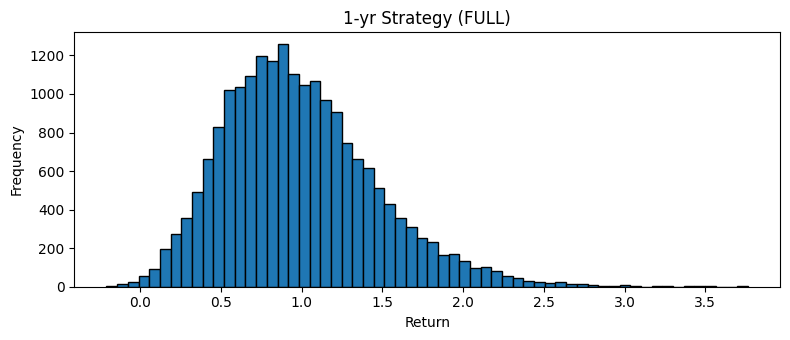


── 1-yr Benchmark (FULL) ──
Mean  :  19.6922%
Median:  18.9712%
5th % : -9.0117%
95th %:  50.6265%


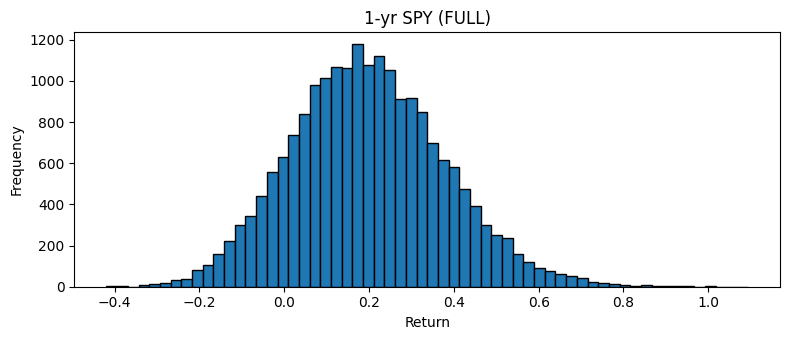


── 1-yr Equal-Weight ──
Mean  :  43.8718%
Median:  37.5382%
5th % : -16.1378%
95th %:  125.2472%


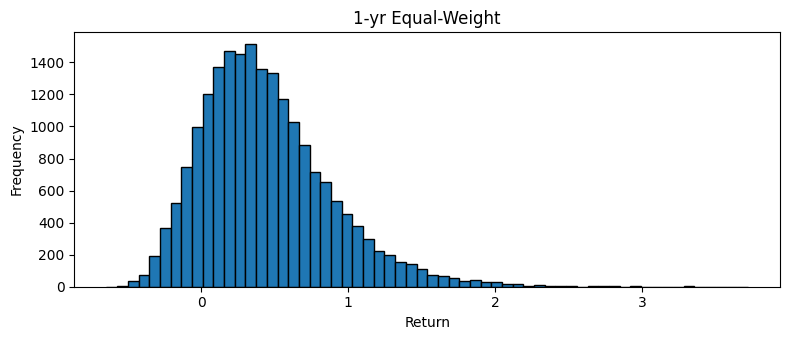


── 1-yr Alpha (S - B) ──
Mean  :  79.0855%
Median:  74.5099%
5th % :  23.4010%
95th %:  150.2963%


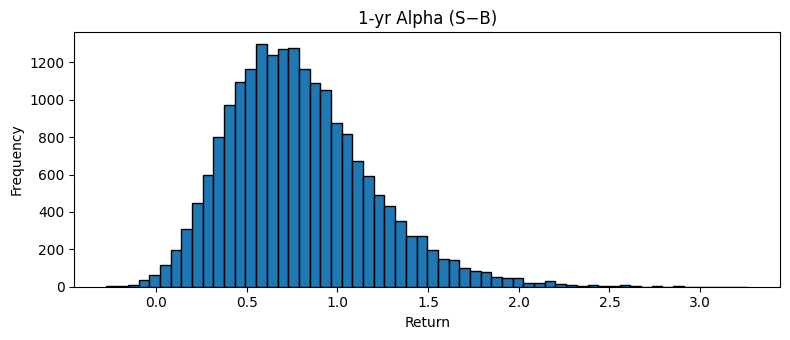

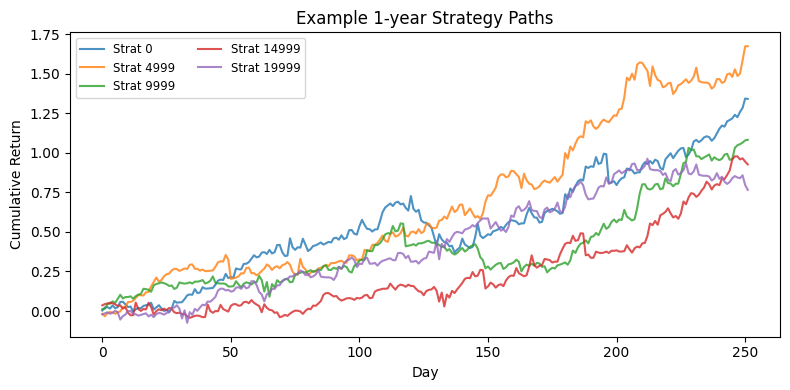

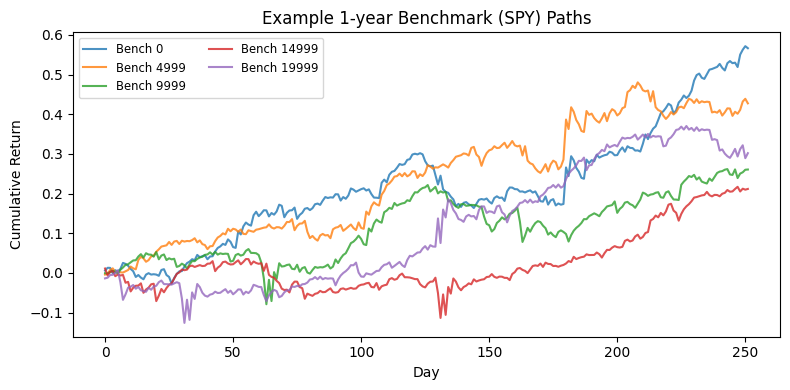

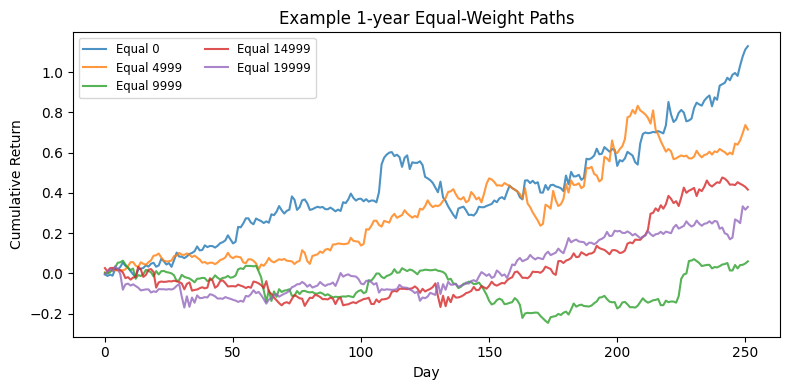

In [4]:
#!/usr/bin/env python3
# ======================================================================
#  Monte-Carlo back-test: strategy vs. SPY with DAY & NIGHT sessions
#  • Plus example 1-year path plots for Strategy, Benchmark, Equal-Weight
# ======================================================================
import math
import pickle
import re
from pathlib import Path

import numpy as np
import pandas as pd
import yfinance as yf
import torch
import matplotlib.pyplot as plt

# ─── CONFIG ────────────────────────────────────────────────────────────
TICKERS = {
    # existing
    "FBK": "XLF", "BANR": "^SP500-40", "PNFP": "^SP500-40",
    "COP": "XLE", "DK": "XLE", "EPD": "XLE", "MPC": "XLE", "WMB": "XLE",
    "TSLA": "XLK",
    # new healthcare names (all XLV except AMED)
    "MASI": "XLV", "LFMD": "XLV", "LMAT": "XLV", "ICAD": "XLV",
    "HAE":  "XLV", "EHC":  "XLV", "CAH":  "XLV",
    "AMED": "XLF",
}
NIGHT_TICKERS = {"MPC", "TSLA"}       # only these have NIGHT_* models
INDEX_TICKER  = "SPY"
START_DATE    = "2024-01-17"

SEQ_LEN     = 5
THRESHOLD   = 0.80
N_PATHS     = 20_000
DAY_HORIZON = 252
BLOCK_DAYS  = 10

DATA_DIR = Path("/Users/derek/Documents/QuantProject")
DEVICE   = torch.device("cpu")


# ─── Helper: variable-depth LSTM ───────────────────────────────────────
class LSTM(torch.nn.Module):
    def __init__(self, n_in, n_layers):
        super().__init__()
        drop = 0.2 if n_layers > 1 else 0.0
        self.lstm = torch.nn.LSTM(n_in, 512, n_layers,
                                  batch_first=True, dropout=drop)
        self.fc   = torch.nn.Linear(512, 1)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return torch.sigmoid(self.fc(h[-1])).squeeze()


def load_model_scaler(sym: str, night: bool):
    tag  = "NIGHT_" if night else ""
    mdl  = DATA_DIR / f"{tag}best_model_{sym}.pth"
    scl  = DATA_DIR / f"{tag}scaler_{sym}.pkl"
    if not mdl.exists() or not scl.exists():
        raise SystemExit(f"❌ Missing {tag}files for {sym}")

    mu, sig = pickle.load(open(scl, "rb"))
    state   = torch.load(mdl, map_location=DEVICE)
    layers  = max(
        (int(m.group(1)) for k in state
         if (m := re.search(r"lstm\.weight_ih_l(\d+)", k))),
        default=0
    ) + 1
    net = LSTM(len(mu), layers).to(DEVICE)
    net.load_state_dict(state, strict=False)
    net.eval()
    return net, (np.asarray(mu, np.float32), np.asarray(sig, np.float32))


# ─── 1 ▸ load models & scalers ─────────────────────────────────────────
DAY_MODELS,   DAY_SCALERS = {}, {}
NIGHT_MODELS, NIGHT_SCALERS = {}, {}
FEATS = {}

for sym, sec in TICKERS.items():
    # DAY
    dm, (mu, sig) = load_model_scaler(sym, night=False)
    DAY_MODELS[sym], DAY_SCALERS[sym] = dm, (mu, sig)
    # NIGHT
    if sym in NIGHT_TICKERS:
        nm, (mu_n, sig_n) = load_model_scaler(sym, night=True)
        NIGHT_MODELS[sym], NIGHT_SCALERS[sym] = nm, (mu_n, sig_n)
    # feature columns
    base = ["Open", "High", "Low", "Close", "Volume"]
    FEATS[sym] = [f"{c}_{sym}" for c in base] + [f"{c}_{sec}" for c in base]
    print(
        f"🔓 {sym}: DAY {dm.lstm.num_layers}-layer"
        + (f" | NIGHT {NIGHT_MODELS[sym].lstm.num_layers}-layer"
           if sym in NIGHT_TICKERS else "")
        + f" (features={len(FEATS[sym])})"
    )


# ─── 2 ▸ download daily bars ───────────────────────────────────────────
print("\n▼ Downloading daily bars…")
symbols = list(TICKERS) + list(set(TICKERS.values())) + [INDEX_TICKER]
df = yf.download(
    symbols, start=START_DATE, interval="1d",
    group_by="column", auto_adjust=False, progress=False
)
if df.empty:
    raise SystemExit("❌ No data returned")

# flatten multiindex
df.columns = [f"{c}_{s}" for c, s in df.columns]
df.dropna(inplace=True)
print(f"✔ {len(df):,} sessions  {df.index[0].date()} → {df.index[-1].date()}")

idx_o, idx_c = f"Open_{INDEX_TICKER}", f"Close_{INDEX_TICKER}"


def seq(sym, i, scaler):
    blk = df.iloc[i - SEQ_LEN : i][FEATS[sym]].values.astype(np.float32)
    mu, sig = scaler
    blk = (blk - mu) / sig
    return torch.tensor(blk[None], dtype=torch.float32, device=DEVICE)


# ─── 3 ▸ compute DAY, NIGHT and FULL returns ───────────────────────────
ret_day, ret_bench_day, ret_equal_day = [], [], []
ret_night, ret_bench_night, ret_equal_night = [], [], []

for i in range(SEQ_LEN, len(df) - 1):
    row_today    = df.iloc[i]
    row_tomorrow = df.iloc[i + 1]

    # DAY benchmark
    bench_d = (row_today[idx_c] - row_today[idx_o]) / row_today[idx_o]
    ret_bench_day.append(bench_d)

    # DAY equal-weight
    eq_d = np.mean([
        (row_today[f"Close_{s}"] - row_today[f"Open_{s}"]) /
        row_today[f"Open_{s}"] for s in TICKERS
    ])
    ret_equal_day.append(eq_d)

    # DAY strategy
    probs_d = {s: DAY_MODELS[s](seq(s, i, DAY_SCALERS[s])).item() for s in TICKERS}
    act_d   = {s: p for s, p in probs_d.items() if p >= THRESHOLD}
    if act_d:
        buckets = {}  # ← fixed initialization
        for s, p in act_d.items():
            buckets.setdefault(TICKERS[s], {})[s] = p
        w_sec = 1 / len(buckets)
        r_d = 0.0
        for sec, bucket in buckets.items():
            tot = sum(bucket.values())
            for s, p in bucket.items():
                r_d += (w_sec * (p / tot)) * (
                    (row_today[f"Close_{s}"] - row_today[f"Open_{s}"]) /
                    row_today[f"Open_{s}"]
                )
    else:
        r_d = bench_d
    ret_day.append(r_d)

    # NIGHT benchmark
    bench_n = (row_tomorrow[idx_o] - row_today[idx_c]) / row_today[idx_c]
    ret_bench_night.append(bench_n)

    # NIGHT equal-weight
    eq_n = np.mean([
        (row_tomorrow[f"Open_{s}"] - row_today[f"Close_{s}"]) /
        row_today[f"Close_{s}"] for s in NIGHT_TICKERS
    ])
    ret_equal_night.append(eq_n)

    # NIGHT strategy
    probs_n = {s: NIGHT_MODELS[s](seq(s, i, NIGHT_SCALERS[s])).item() for s in NIGHT_TICKERS}
    act_n   = {s: p for s, p in probs_n.items() if p >= THRESHOLD}
    if act_n:
        buckets_n = {}  # ← fixed initialization
        for s, p in act_n.items():
            buckets_n.setdefault(TICKERS[s], {})[s] = p
        w_sec_n = 1 / len(buckets_n)
        r_n = 0.0
        for sec, bucket in buckets_n.items():
            tot = sum(bucket.values())
            for s, p in bucket.items():
                r_n += (w_sec_n * (p / tot)) * (
                    (row_tomorrow[f"Open_{s}"] - row_today[f"Close_{s}"]) /
                    row_today[f"Close_{s}"]
                )
    else:
        r_n = bench_n
    ret_night.append(r_n)

# convert to np arrays
ret_day    = np.asarray(ret_day)
ret_night  = np.asarray(ret_night)
ret_full   = (1 + ret_day) * (1 + ret_night) - 1

ret_bench_day   = np.asarray(ret_bench_day)
ret_bench_night = np.asarray(ret_bench_night)
ret_bench_full  = (1 + ret_bench_day) * (1 + ret_bench_night) - 1

ret_equal_day   = np.asarray(ret_equal_day)
ret_equal_night = np.asarray(ret_equal_night)
ret_equal_full  = (1 + ret_equal_day) * (1 + ret_equal_night) - 1


# quick stats
def quick(label, arr):
    print(f"{label:<12} μ={arr.mean():+.4%}  σ={arr.std():.4%}")

print("\nDaily return stats:")
quick("STRAT-DAY",  ret_day)
quick("STRAT-NITE", ret_night)
quick("STRAT-FULL", ret_full)
quick("BENCH-FULL", ret_bench_full)
quick("EQ-FULL",    ret_equal_full)


# ─── 4 ▸ bootstrap 1-year paths ────────────────────────────────────────
def paired_boot(arr_s, arr_b, arr_e, n_paths, horizon, blk):
    T = len(arr_s)
    k = math.ceil(horizon / blk)
    rng = np.random.default_rng(42)
    S = np.empty((n_paths, horizon))
    B = np.empty_like(S)
    E = np.empty_like(S)
    for p in range(n_paths):
        starts = rng.integers(0, T - blk + 1, size=k)
        S[p] = np.concatenate([arr_s[s:s+blk] for s in starts])[:horizon]
        B[p] = np.concatenate([arr_b[s:s+blk] for s in starts])[:horizon]
        E[p] = np.concatenate([arr_e[s:s+blk] for s in starts])[:horizon]
    return S, B, E


S, B, E = paired_boot(ret_full, ret_bench_full, ret_equal_full,
                      N_PATHS, DAY_HORIZON, BLOCK_DAYS)
S_c = (1 + S).cumprod(axis=1) - 1
B_c = (1 + B).cumprod(axis=1) - 1
E_c = (1 + E).cumprod(axis=1) - 1
A_c = S_c - B_c


# ─── 5 ▸ reporting & plots ────────────────────────────────────────────
def summary(name, arr):
    print(f"\n── 1-yr {name} ──")
    print(f"Mean  : {arr.mean(): .4%}")
    print(f"Median: {np.median(arr): .4%}")
    print(f"5th % : {np.percentile(arr,5): .4%}")
    print(f"95th %: {np.percentile(arr,95): .4%}")


def hist(title, arr):
    plt.figure(figsize=(8,3.5))
    plt.hist(arr, bins=60, edgecolor='black')
    plt.title(title); plt.xlabel("Return"); plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


# print summaries and histograms
summary("Strategy (FULL)",  S_c[:, -1])
hist("1-yr Strategy (FULL)", S_c[:, -1])

summary("Benchmark (FULL)", B_c[:, -1])
hist("1-yr SPY (FULL)", B_c[:, -1])

summary("Equal-Weight",     E_c[:, -1])
hist("1-yr Equal-Weight",     E_c[:, -1])

summary("Alpha (S - B)",      A_c[:, -1])
hist("1-yr Alpha (S−B)",       A_c[:, -1])


# ─── 6 ▸ example sample paths ─────────────────────────────────────────
n_examples = 5
example_idxs = np.linspace(0, N_PATHS-1, n_examples, dtype=int)

plt.figure(figsize=(8,4))
for idx in example_idxs:
    plt.plot(S_c[idx], alpha=0.8, label=f"Strat {idx}")
plt.title("Example 1-year Strategy Paths")
plt.xlabel("Day")
plt.ylabel("Cumulative Return")
plt.legend(ncol=2, fontsize='small')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
for idx in example_idxs:
    plt.plot(B_c[idx], alpha=0.8, label=f"Bench {idx}")
plt.title("Example 1-year Benchmark (SPY) Paths")
plt.xlabel("Day")
plt.ylabel("Cumulative Return")
plt.legend(ncol=2, fontsize='small')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
for idx in example_idxs:
    plt.plot(E_c[idx], alpha=0.8, label=f"Equal {idx}")
plt.title("Example 1-year Equal-Weight Paths")
plt.xlabel("Day")
plt.ylabel("Cumulative Return")
plt.legend(ncol=2, fontsize='small')
plt.tight_layout()
plt.show()